<a href="https://colab.research.google.com/github/howonJeong/Stock-Prediction-by-Option-IV/blob/main/ch7to8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np, cv2
from google.colab.patches import *


Mounted at /content/drive


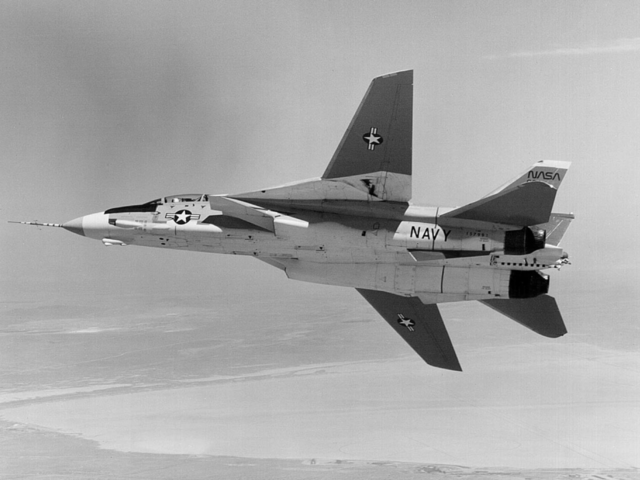

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/MAICON/images/f14.tif'
f14 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

cv2_imshow(f14)

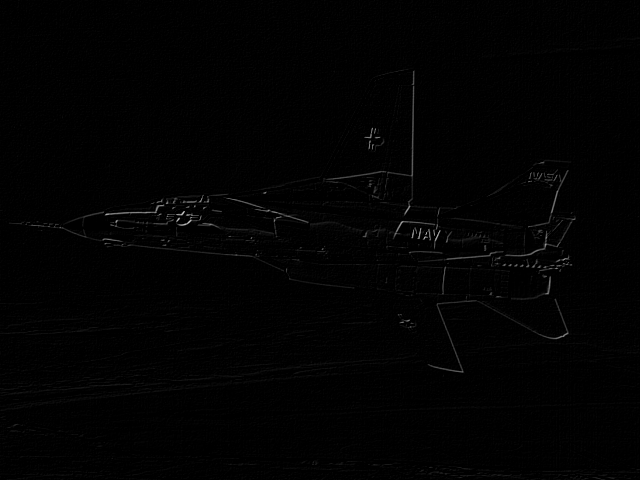

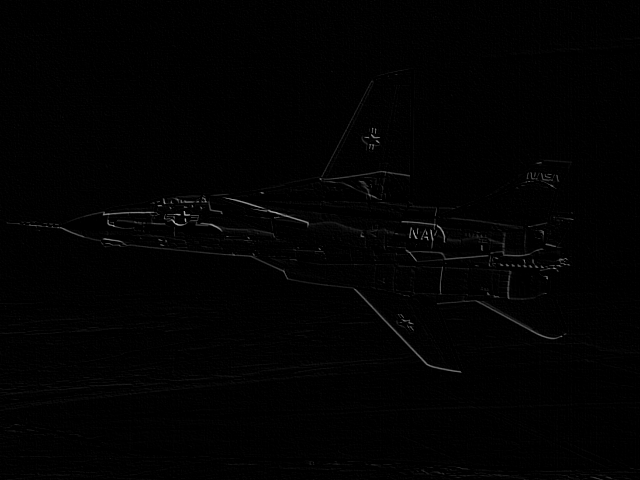

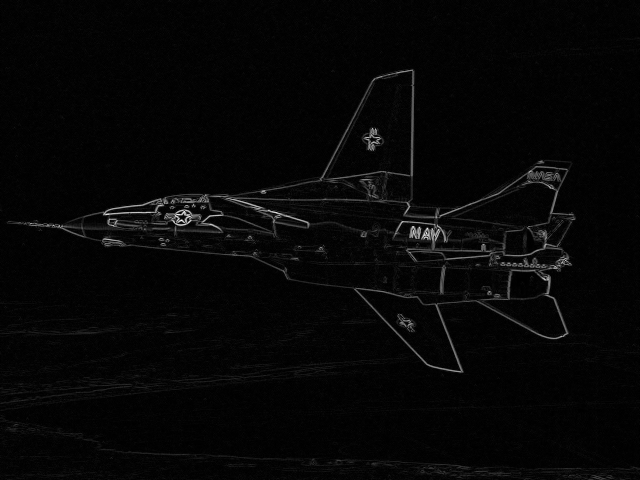

In [4]:
kernel_x = np.array([[-1,0,0],
                     [0,1,0],
                     [0,0,0]], dtype=np.float32)

kernel_y = np.array([[0,0,-1],
                     [0,1,0],
                     [0,0,0]], dtype=np.float32)

prewitt_x = cv2.filter2D(f14, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(f14, cv2.CV_64F, kernel_y)

cv2_imshow(prewitt_x)
cv2_imshow(prewitt_y)

magnitude = cv2.magnitude(prewitt_x, prewitt_y)

magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

cv2_imshow(magnitude)

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from ipywidgets import interact, IntSlider, FloatSlider


def update(low=50, high=150):
    edges = cv2.Canny(f14, low, high)

    # 에지(그레이스케일 1채널)를 컬러 이미지 위에 겹쳐서 보여주기
    edges_colored = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    combined = np.hstack((f14, edges_colored))

    cv2_imshow(combined)

interact(
    update,
    low=IntSlider(min=0, max=255, step=1, value=50, description='threshold1'),
    high=IntSlider(min=0, max=255, step=1, value=150, description='threshold2')
)

interactive(children=(IntSlider(value=50, description='threshold1', max=255), IntSlider(value=150, description…

<function __main__.update(low=50, high=150)>

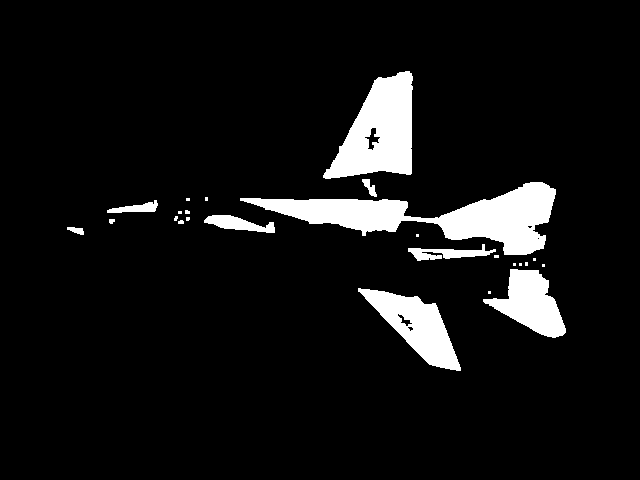

In [6]:
_, binary = cv2.threshold(cv2.bitwise_not(f14), 160, 255, cv2.THRESH_BINARY)

kernel = np.ones((3,3), np.uint8)

eroded = cv2.erode(binary, kernel, iterations=1)
closed = cv2.dilate(eroded, kernel, iterations=1)

cv2_imshow(closed)

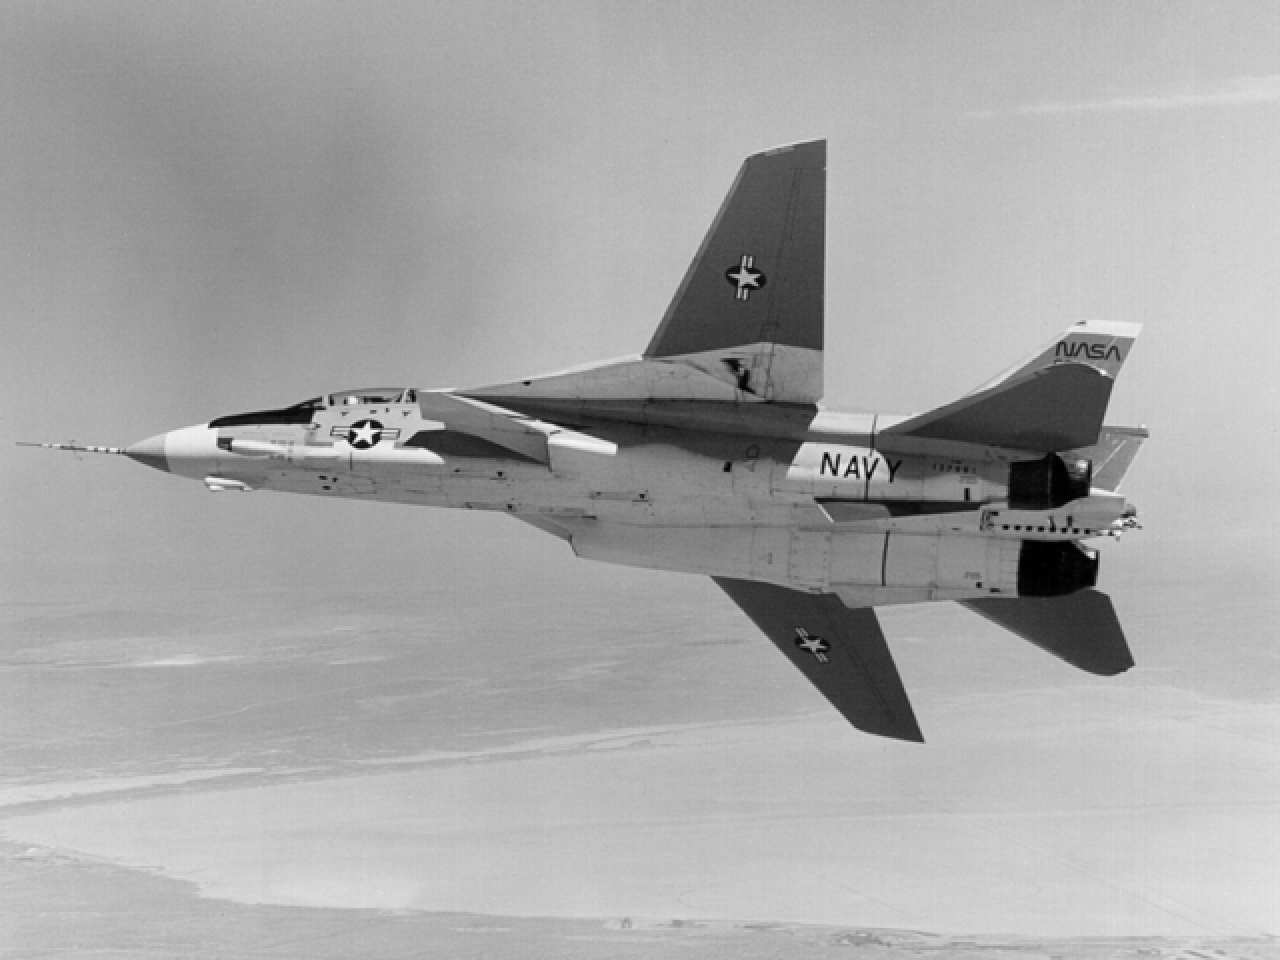

In [7]:
h, w = f14.shape[:2]
enlarged = cv2.resize(f14, (w*2, h*2), interpolation=cv2.INTER_NEAREST)

cv2_imshow(enlarged)

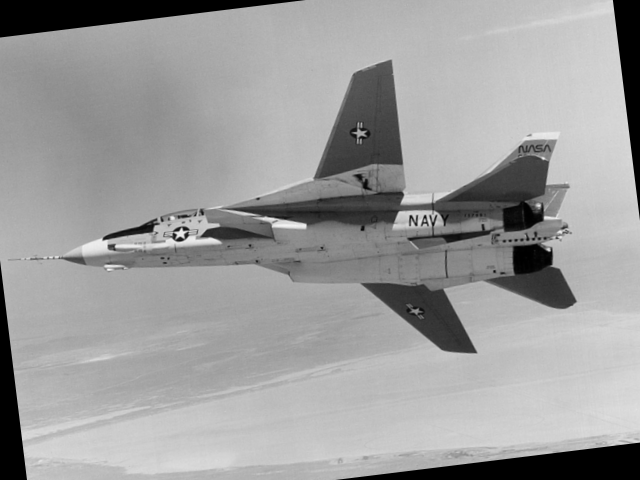

In [8]:
center = (w // 2, h // 2)   # 회전 중심점 (보통 이미지 중앙)
angle = 7                  # 회전 각도
scale = 1.0                 # 크기 배율 (1.0 = 원본 크기 유지)

M = cv2.getRotationMatrix2D(center, angle, scale)   # 회전 행렬(2x3) 생성
rotated = cv2.warpAffine(f14, M, (w, h))            # 실제 회전 적용
cv2_imshow(rotated)

In [9]:
h, w = f14.shape[:2]
points = [(50, 50), (200, 50), (50, 200)]   # 원본 기준 점 (함수 밖에 둬도 됨, 안 바뀌는 값이니까)

def update(angle=0, scale=1.0):
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    rotated = cv2.warpAffine(f14, M, (w, h))

    pts_array = np.array([points], dtype=np.float32)
    transformed_pts = cv2.transform(pts_array, M)[0]

    for i, (x, y) in enumerate(transformed_pts):
        x, y = int(x), int(y)
        cv2.circle(rotated, (x, y), radius=5, color=(0, 0, 255), thickness=-1)
        cv2.putText(rotated, f'P{i}', (x+10, y), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0, 255, 0), 2)

    cv2_imshow(rotated)

interact(
    update,
    angle=IntSlider(min=0, max=360, step=5, value=0, description='angle'),
    scale=FloatSlider(min=0.2, max=5, step=0.2, value=1.0, description='scale')
)

interactive(children=(IntSlider(value=0, description='angle', max=360, step=5), FloatSlider(value=1.0, descrip…

<function __main__.update(angle=0, scale=1.0)>

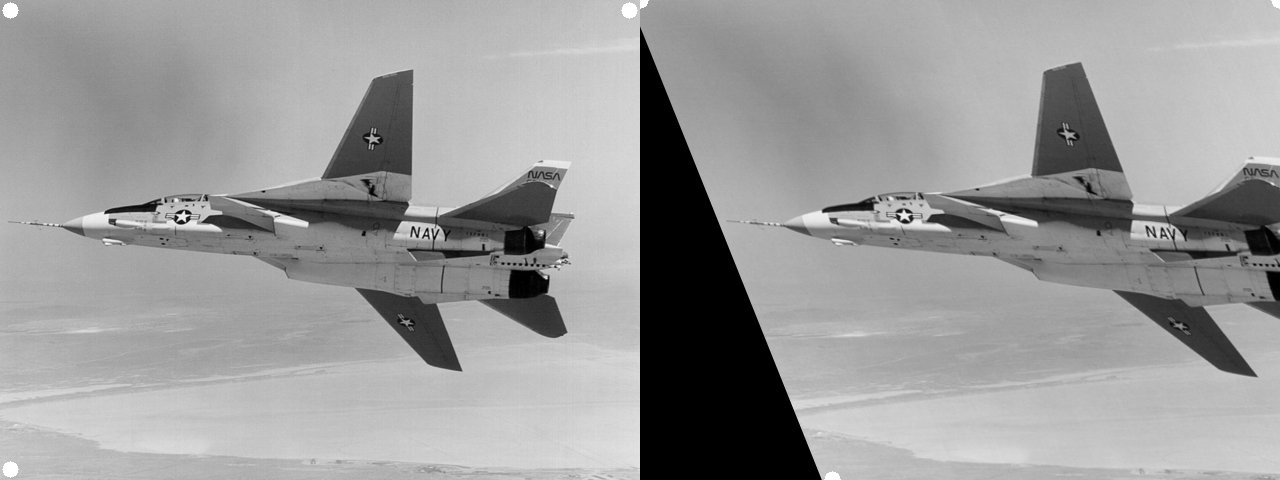

In [10]:
h, w = f14.shape[:2]

pts1 = np.float32([[10, 10], [w-11, 10], [10, h-11]])
pts2 = np.float32([[0, 0], [w-1, 0], [int(w*0.3), h-1]])  # 좌하단만 오른쪽으로 밀기 → 전단 효과

M = cv2.getAffineTransform(pts1, pts2)
result = cv2.warpAffine(f14, M, (w, h))

f14_ori = f14.copy()
for (x, y) in pts1:
    cv2.circle(f14_ori, (int(x), int(y)), 8, (255, 255), -1)

f14_aft = result.copy()
for (x, y) in pts2:
    cv2.circle(f14_aft, (int(x), int(y)), 8, (255, 255), -1)

combined = np.hstack((f14_ori, f14_aft))
cv2_imshow(combined)

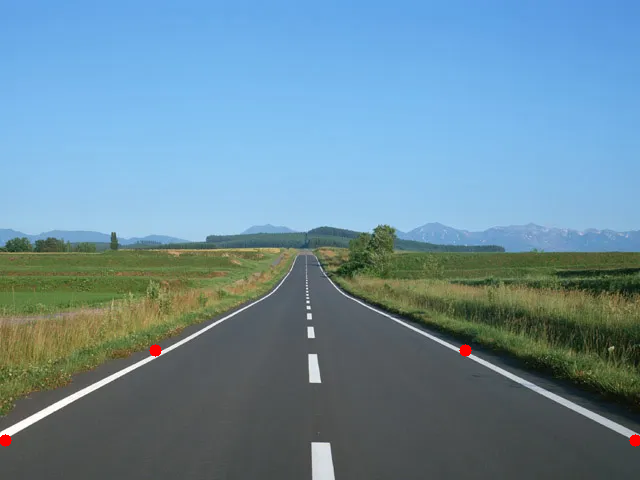

(480, 640)


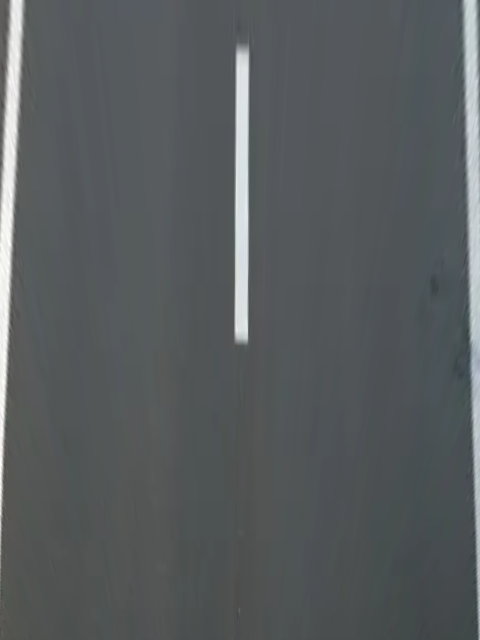

In [40]:
roadline_path = '/content/drive/MyDrive/MAICON/images/roadline.png'
roadline = cv2.imread(roadline_path, cv2.IMREAD_COLOR)

import matplotlib.pyplot as plt
roadline_before = roadline.copy()
pts1 = np.float32([
    [155, 350],
    [465, 350],
    [635, 440],
    [5,  440]
])

for (x, y) in pts1:
    cv2.circle((roadline_before), (int(x), int(y)), 6, (0, 0, 255), -1)

cv2_imshow(roadline_before)

w, h = roadline.shape[:2]

pts2 = np.float32([
    [0,   0],
    [w-1, 0],
    [w-1, h-1],
    [0,   h-1]
])

M = cv2.getPerspectiveTransform(pts1, pts2)
result = cv2.warpPerspective(roadline, M, (w, h))

print(roadline.shape[:2])
cv2_imshow(result)